# Conditional LLM Workflow
### -- Customer Support --

In [108]:
# libraries
from langgraph.graph import StateGraph
from langgraph.graph import START, END
from langchain_groq.chat_models import ChatGroq
from typing import Annotated, TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
import os

In [109]:
# load api key
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [110]:
# define LLM model
llm_model = ChatGroq(
    model = "llama-3.3-70b-versatile",
    temperature = 0,
    max_tokens = None
)

In [111]:
# define schema for structured output
class SentimentSchema(BaseModel):
    sentiment: Literal["Positive", "Negative"] = Field(description = "Sentiment of the review")

In [112]:
# define diagnosis schema
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description = "The category of issue mentioned in this review")
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description = "The emotional tone expressed by the user")
    urgency: Literal["Low", "Medium", "High"] = Field(description = "How urgent or critical the issue it appears to be")

In [113]:
# pass schema to LLM model
structured_model = llm_model.with_structured_output(SentimentSchema)
structured_model_2 = llm_model.with_structured_output(DiagnosisSchema)

In [114]:
# sample
prompt = "What is the sentiment of this review - The software is too good"
structured_model.invoke(prompt)

SentimentSchema(sentiment='Positive')

In [115]:
# define state
class ReviewState(TypedDict):
    review: str
    sentiment: Literal["Positive", "Negative"]
    diagnosis: dict
    response: str

In [116]:
# define function
def find_sentiment(state: ReviewState):
    prompt = f"For the following review find out the sentiment \n {state["review"]}"
    output = structured_model.invoke(prompt)

    return {"sentiment": output}

In [117]:
# define function
def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state["sentiment"].sentiment == "Positive":
        return "positive_response"
    else:
        return "run_diagnosis"

In [118]:
# define function
def positive_response(state: ReviewState):
    prompt = f'Write a warm thank you message in response to this review \n\n {state["review"]} \n\n Also kindly ask the user to leave a feedback on our website.'
    output = llm_model.invoke(prompt).content

    return {"response": output}

In [119]:
# define function
def run_diagnosis(state: ReviewState):
    prompt = f'Diagnosis this negative review: \n\n {state["review"]}\n Return issue_type, tone and urgency'
    output = structured_model_2.invoke(prompt)

    return {"diagnosis": output.model_dump()}

In [120]:
# define negative
def negative_response(state: ReviewState):
    diagnosis = state["diagnosis"]
    prompt = f'You are a support assistant. The user had a {diagnosis["issue_type"]} issue, sounded {diagnosis["tone"]} and marked urgency as {diagnosis["urgency"]}. Write a short, empathetic, and professional response that apologizes, acknowledges their frustration, and reassures them that the issue will be addressed.'
    output = llm_model.invoke(prompt)
    
    return {"response": output.content}

In [121]:
# define graph
graph = StateGraph(ReviewState)

# nodes
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("positive_response", positive_response)
graph.add_node("run_diagnosis", run_diagnosis)
graph.add_node("negative_response", negative_response)
graph.add_node("check_sentiment", check_sentiment)

# edges
graph.add_edge(START, "find_sentiment")
graph.add_conditional_edges("find_sentiment", check_sentiment)

graph.add_edge("positive_response", END)

graph.add_edge("run_diagnosis", "negative_response")
graph.add_edge("negative_response", END)
# compile
workflow = graph.compile()

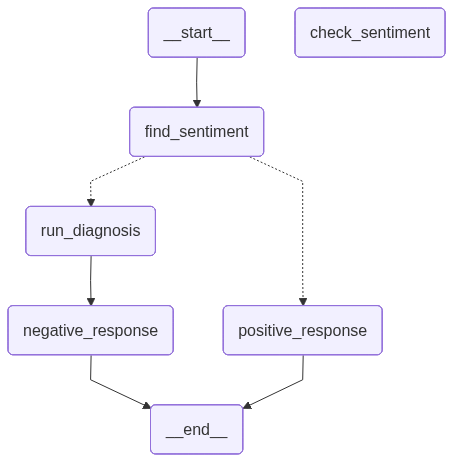

In [122]:
workflow

In [123]:
# execute
initial_state = {
    "review": "I absolutely loved this product! The quality is excellent, it works smoothly, and the user experience is fantastic. Totally worth it!"
}
workflow.invoke(initial_state)

{'review': 'I absolutely loved this product! The quality is excellent, it works smoothly, and the user experience is fantastic. Totally worth it!',
 'sentiment': SentimentSchema(sentiment='Positive'),
 'response': "Dear valued customer,\n\nWe are absolutely thrilled to hear that you're loving our product! We're so glad to know that the quality, performance, and user experience have all met your expectations. Your satisfaction means the world to us, and we're grateful for your kind words.\n\nAs a small token of our appreciation, we'd like to thank you for being an amazing customer! We're honored to have you as part of our community.\n\nIf you have a moment, we'd be ever so grateful if you could also share your wonderful experience on our website. Your feedback will help others make informed decisions and will also help us continue to improve and provide the best possible products and services. You can leave your review by visiting [website link].\n\nOnce again, thank you for your wonder